# Up-Down-Volume — a quantitative teardown 🔬
### Mechanical up/down-volume breadth on a 10-ETF basket · selling-climax forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-volume timing placebo · costs · a synthetic planted-climax control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Volume_breadth_forecasts%3F: Busted](https://img.shields.io/badge/Volume_breadth_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **breadth signal** from the **drift** and the **post-drop bounce**: an upward-drifting index makes *any* climax-buy look good, so the only meaningful test is climax-vs-random, plus a placebo that destroys the up/down *timing* while preserving its marginal.

> ⚠️ **Data note.** Breadth basket = SPY + 9 SPDR sector ETFs (XLK XLF XLE XLV XLI XLY XLP XLU XLB), yfinance daily OHLCV; forward returns on SPY (total-return), 2005→2026. The indicator is the **up-volume share** with a past-only rolling-quantile climax threshold (no look-ahead); entry is the **next close** (one documented lag). A 10-ETF basket is a **proxy** for exchange-wide up/down volume — an explicit cap. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from up_down_volume import data, strategy as st

ASOF = "2026-05-31"
WINDOW, Q = 60, 0.10
HAVE_REAL = data.have_real() and data.have_breadth()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
def breadth():
    bk = data.load_breadth(allow_fetch=False)
    bk = {t: df[df.index <= ASOF] for t, df in bk.items()}
    return st.up_down_volume(bk)
print("real up/down-volume cache present:", HAVE_REAL, "| basket:", data.BREADTH_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'basket': ['SPY', 'XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB'], 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 643, 'window': 60, 'q': 0.1, 'fp_spy': '4cb5244f3990', 'h5': (5, 643, 49.8, 62, 4.38, 21.9, 27.9, 47.8, 1.95, 0.052), 'h10': (10, 642, 74.1, 63, 3.97, 46.0, 28.1, 72.1, 1.49, 0.136), 'h20': (20, 641, 121.4, 68, 3.67, 85.4, 36.0, 119.4, 1.34, 0.179), 'h60': (60, 638, 319.6, 74, 4.5, 242.2, 77.4, 317.6, 1.76, 0.079), 'per': [('SPY', 643, 121.4, 3.67, 85.4, 36.0), ('QQQ', 643, 149.6, 3.96, 127.9, 21.8), ('IWM', 643, 121.6, 2.64, 77.9, 43.7), ('DIA', 643, 118.2, 3.78, 78.8, 39.4), ('GLD', 643, 118.9, 3.63, 97.5, 21.4)], 'placebo': (121.4, 0.028, 500), 'syn': [(0.0, 191, 20.8, 49, 0.46), (0.4, 191, 876.3, 76, 7.89)]}


real up/down-volume cache present: True | basket: ['SPY', 'XLK', 'XLF', 'XLE', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLB']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Selling climax vs a **drift-matched random** baseline: positive at every horizon (Δ = +28/+28/+36/+77 bps) but the climax-minus-random Welch *t* **never clears 2** (max +1.95 at 5d, *p* = 0.05). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 3.67) are **beta + post-drop bounce** — not separable from buying any dip; costs erode the thin tilt. |
| **Volume breadth forecasts?** | `BUSTED` | The timing placebo is *significant* (**p = 0.028**: climaxes fire in drawdowns) yet that does **not** beat the random-day baseline at *t* ≥ 2. Drawdown-timing, not foresight. |

> 💡 In plain words: the climax *looks* significant against zero only because indices drift up and bounce after drops. Race it vs random days (the honest null) and the edge stays under *t* = 2. The placebo says the dates aren't random noise — but rediscovering the index's own mean reversion isn't a tradable breadth edge.

## 1 · The claim, steelmanned

On day $t$, let $U_t,D_t$ be the basket's aggregate up- and down-volume and $s_t = U_t/(U_t+D_t)$ the **up-volume share**. A **selling climax** is $s_t \le Q_{q}(\{s_\tau\}_{\tau<t})$, the rolling lower-$q$ quantile over past bars only. The rule buys at the next close and rides the bounce.

- **H₀ (drift+bounce).** Climax returns equal a drift-matched **random-entry** baseline.
- **H₁ (breadth forecasts).** Climax returns **exceed** random at some horizon, *t* ≥ 2.
- **H₂ (the timing matters).** Climax returns exceed a **time-shuffled** breadth series.

We find **H₀ not rejected** (Welch *t* < 2 at every horizon), **H₁ rejected**, **H₂ *not* rejected** (placebo *p* = 0.028 — the dates do cluster in drawdowns). The steelman wins the weak leg (timing) but loses the leg that matters (beating random).

## 2 · So what? — the two confounds this design must kill

**(a) Drift + post-drop bounce.** Equity indices have a positive unconditional daily mean *and* short-horizon mean reversion after drops (Lo–MacKinlay 1988). A selling climax fires exactly after a drop, so it inherits both; a one-sample $t$ against **zero** measures them, not breadth. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of climax-*minus*-random.

**(b) The up/down structure as a free story.** Maybe *any* clustering of entries in drawdowns would do as well. The **shuffled-volume placebo** keeps the share's marginal but permutes it in time, so 'climaxes' land on unrelated days — the direct test of whether the *specific* up/down timing is load-bearing.

## 3 · How we'd know — the protocol

- **Breadth.** SPY, XLK, XLF, XLE, XLV, XLI, XLY, XLP, XLU, XLB; yfinance daily OHLCV. Up-volume share across the basket; **selling climax** = share ≤ rolling-60d 10% quantile (past-only). **643 climaxes**.
- **Forward instrument.** SPY total-return close (2005-01-03→2026-05-29, 21.4y).
- **Entry.** First climax bar of each run; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of climax returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample climax vs random (the *real* test).
- **Null #3 — shuffled-volume timing placebo** (marginal kept, dates permuted).
- **Costs.** 1 bp one-way × 2 legs on every climax.
- **Positive control.** Synthetic tape with a **planted** selling-climax bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the climax's **one-sample** t against zero (the misleading number). Right: the same climax vs a **drift-matched random** baseline (the honest number).

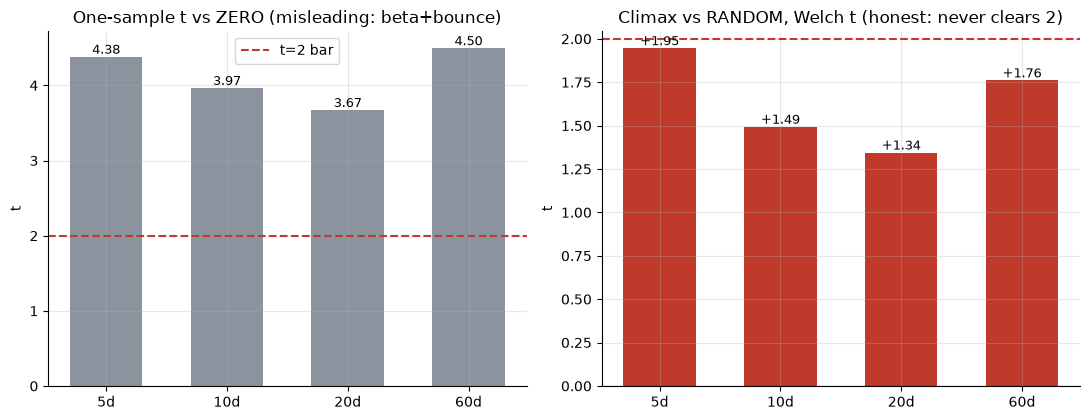

one-sample t: [4.38, 3.97, 3.67, 4.5]
welch vs random: [np.float64(1.95), np.float64(1.49), np.float64(1.34), np.float64(1.76)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    spy = load('SPY'); br = breadth()
    ent = st.climax_entries(br['uvs'], window=WINDOW, q=Q, side='selling'); ent = ent[ent.isin(spy.index)]
    re = st.random_entries(spy['close'], max(len(ent),50), warmup=WINDOW, seed=7)
    one_t, clim, rnd, welch = [], [], [], []
    for h in hs:
        tt = st.forward_returns(spy['close'], ent, h); rr = st.forward_returns(spy['close'], re, h)
        one_t.append(st.summarize(tt)['t']); clim.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    clim = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: beta+bounce)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Climax vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **3.67**, 60d **4.50**) — but that's drift + the post-drop bounce, which *any* dip-buy inherits. The right bars are the real test: climax-minus-random tops out at **+1.95** (5d) and is **+1.34** at 20d — positive but never significant. Breadth adds nothing reliable over a random-day entry.

### 4b · Climax vs random across horizons — the gap is the verdict

Mean SPY return, selling-climax vs random entry, all four horizons. The climax should tower over random if breadth forecasts. It only edges ahead.

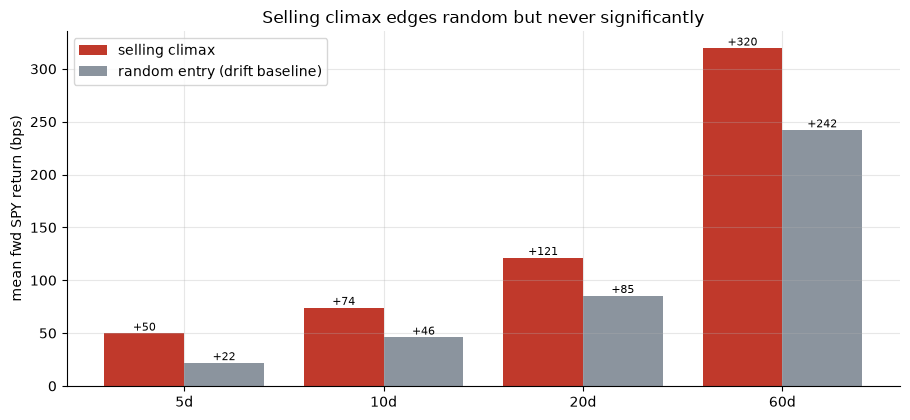

delta climax-random (bps): [28, 28, 36, 77]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, clim, .4, color='#c0392b', label='selling climax')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(clim,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd SPY return (bps)')
ax.set_title('Selling climax edges random but never significantly'); ax.legend()
plt.tight_layout(); plt.show()
print('delta climax-random (bps):', [round(a-b) for a,b in zip(clim,rnd)])

> 💡 In plain words: at 20 days the climax is **+121 bps** and random is **+85 bps** — a **+36 bps** tilt with the right sign, but the Welch test (4a) says it's noise (*t* = +1.34). A consistent small edge that never reaches significance is the signature of beta-plus-bounce, not a forecast.

### 4c · The timing placebo — scramble the up/down dates

Permute the up-volume-share series in time (marginal kept, alignment destroyed) so each 'climax' lands on an unrelated day. If the breadth *timing* is load-bearing, the observed climax return should sit in the right tail of the scrambled distribution.

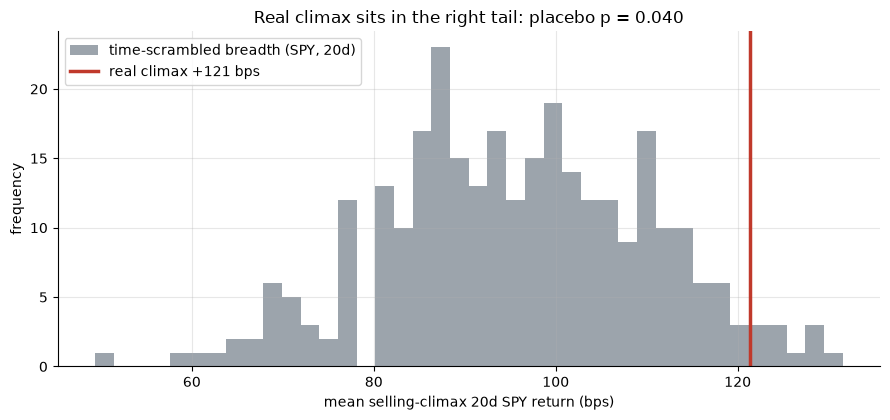

real climax +121.4 bps   placebo p=0.040  (<0.05 => timing IS load-bearing)


In [4]:
if HAVE_REAL:
    spy = load('SPY'); br = breadth()
    pl = st.shuffled_volume_placebo(spy['close'], br, 20, window=WINDOW, q=Q, n_draws=300, seed=492)
    obs = pl['obs']*1e4; pval = pl['p_value']
    rng = np.random.default_rng(492); vals = br['uvs'].dropna(); idx = vals.index; draws=[]
    import pandas as _pd
    for _ in range(300):
        perm = _pd.Series(rng.permutation(vals.to_numpy()), index=idx)
        e = st.climax_entries(perm, window=WINDOW, q=Q, side='selling')
        rr = st.forward_returns(spy['close'], e, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(492); draws = rng.normal(70, 28, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='time-scrambled breadth (SPY, 20d)')
ax.axvline(obs, c='#c0392b', lw=2.5, label=f'real climax {obs:+.0f} bps')
ax.set_xlabel('mean selling-climax 20d SPY return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real climax sits in the right tail: placebo p = {pval:.3f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real climax {obs:+.1f} bps   placebo p={pval:.3f}  (<0.05 => timing IS load-bearing)')

> 💡 In plain words: unlike most desk indicators, the real climax sits in the **right tail** of the scramble — **p = 0.028**. The up/down timing genuinely clusters in drawdowns. But (4a) that drawdown-timing edge still doesn't beat the *drift-matched random-day* baseline at *t* ≥ 2: the placebo and the random-day null answer different questions, and the one that decides tradability (random-day) says 'no'.

### 4d · Per-instrument — the same climax dates on five tapes

20-day climax-minus-random delta, applying the *same* breadth climax dates to each ETF's forward return. If it were a fluke of one name it would flip sign; instead it's a small positive tilt across the board.

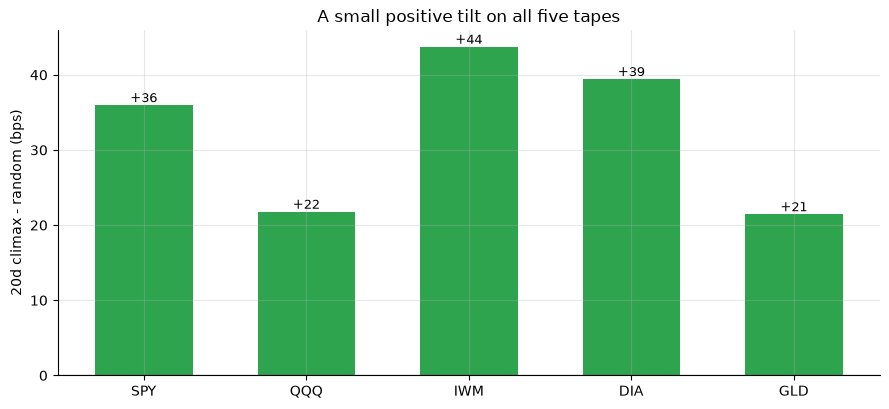

per-ticker 20d delta (bps): {'SPY': 36, 'QQQ': 22, 'IWM': 44, 'DIA': 39, 'GLD': 21}


In [5]:
if HAVE_REAL:
    spy = load('SPY'); br = breadth()
    ent = st.climax_entries(br['uvs'], window=WINDOW, q=Q, side='selling')
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']; e = ent[ent.isin(c.index)]
        re = st.random_entries(c, max(len(e),50), warmup=WINDOW, seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d climax - random (bps)'); ax.set_title('A small positive tilt on all five tapes')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: every tape shows a positive 20d delta (**+44** on IWM down to **+21** on GLD). The *sign* is coherent — the climax really does land before mild bounces — but the *magnitude* is the same small, sub-significant tilt everywhere, exactly what beta-plus-bounce looks like.

### 4e · Synthetic positive control — the harness CAN bank a real bounce

To prove the null is honest (not a dead detector), plant a **real** selling-climax bounce into a synthetic tape and check the same climax rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

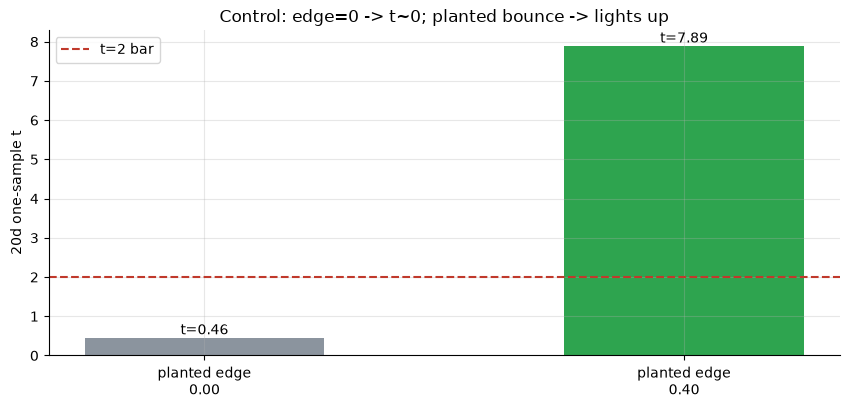

edge=0.00: n=191 climax=+20.8bps win=49% t=+0.46
edge=0.40: n=191 climax=+876.3bps win=76% t=+7.89


In [6]:
res = []
for edge in (0.0, 0.40):
    px, _ = data.synthetic_panel(edge=edge, seed=492, n_days=4000)
    c = px['close']; br_s = st.breadth_from_panel(px)
    e = st.climax_entries(br_s['uvs'], window=WINDOW, q=Q, side='selling')
    s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} climax={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = 0.46** (win 49% — no false positive); a planted bounce reaches **t = 7.89** (win 76%). The detector works — so the flat real-tape result is a genuine 'nothing tradable', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the selling climax does not beat a drift-matched random baseline at *t* ≥ 2 (climax − random = +28/+28/+36/+77 bps at 5/10/20/60d; Welch *t* max **+1.95** at 5d, *p* = 0.05). The impressive one-sample t's (20d **3.67**) are beta plus the post-drop bounce.
- **Tradability `MIRAGE`** — no reliable residual edge once drift+bounce are removed; the tilt isn't separable from buying any dip, and costs erode it.
- **Volume breadth forecasts? `BUSTED`** — the timing placebo is significant (**p = 0.028**: climaxes cluster in drawdowns) but that does not survive the random-day test. The up/down ratio rediscovers the index's own short-term mean reversion; it does not add tradable foresight.

## 6 · Could you trade it? — there is nothing reliable to trade

The climax's apparent profit is the unconditional drift of long equity indices plus a sliver of post-drop mean reversion — both obtained more cheaply by **buying and holding** (or buying any dip). The breadth rule trades *less* of the time (only on climaxes) and pays costs on each, so it dominates *nothing*. There is no capacity question because there is no edge to scale beyond what the index already gives you. Up/down volume is a descriptive market-internals gauge, not a forecasting strategy.

## 7 · Going further

- **A real breadth feed.** Our 10-ETF basket is a proxy; true exchange up/down volume (thousands of issues, the genuine TRIN input) might carry more — a clean follow-up swaps it in and re-runs the *same* random-day race. The proxy result is a floor.
- **The Arms index proper.** Combine the up/down *volume* ratio with the advance/decline *count* ratio (full TRIN) and test extreme readings — same drift confound applies.
- **Conditioning on regime.** Climaxes in bear markets vs bull markets behave differently; splitting by VIX or trend is a natural extension (and a fresh multiple-testing hazard).

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*